# Laboratorio 2 — LSTM
### Data Science | Universidad del Valle de Guatemala
**Sección 10 | Ing. Lynette García**

**Integrantes:** Jose Ordoñez - 231329, Adrián González - 23152, José Antón - 221041

Link de GitHub: https://github.com/Ikeel04/Labs-DS.git

## Ejercicio 1
### 1.1 Conjuntos de entrenamiento y prueba

Se utilizan dos de las series construidas en el Laboratorio 1: **Total mensual** y **Vía Aérea**. Se reconstruyen aplicando exactamente el mismo procedimiento del Laboratorio 1 (misma limpieza, misma exclusión del tipo de viajero con discontinuidad metodológica, mismo corte cronológico 70/30) para garantizar que los conjuntos de entrenamiento y prueba sean idénticos a los usados con los modelos ARIMA/Prophet/Holt-Winters del laboratorio anterior.

In [1]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.rcParams["figure.dpi"] = 100
SPLIT_DATE = pd.Timestamp("2021-04-01")

In [2]:
df = pd.read_excel("Base_Migracion_2009-2026jun.xlsx")
print("Dimensiones:", df.shape)

Dimensiones: (161036, 13)


Se excluyen los registros con `Tipo de Viajero = "Viajero"` por la discontinuidad metodológica 2022-2023 documentada en el Laboratorio 1 (no aplica a Vía Marítima, pero esa serie no se usa en este ejercicio).

In [3]:
df_series = df[df["Tipo de Viajero"] != "Viajero"].copy()

def build_monthly(mask_df):
    mensual = mask_df.groupby(["Año","Mes cod"])["Viajero"].sum().reset_index()
    fechas = pd.to_datetime(dict(year=mensual["Año"], month=mensual["Mes cod"], day=1))
    s = pd.Series(mensual["Viajero"].values, index=pd.DatetimeIndex(fechas))
    full_idx = pd.date_range(s.index.min(), s.index.max(), freq="MS")
    s = s.reindex(full_idx, fill_value=0)
    s.index.freq = "MS"
    return s

ts_total = build_monthly(df_series)
ts_aerea = build_monthly(df_series[df_series["Vía"] == "Aérea"])

series_dict = {
    "total": (ts_total, "Total mensual", "steelblue"),
    "aerea": (ts_aerea, "Vía Aérea", "darkcyan"),
}

for slug, (ts, titulo, _) in series_dict.items():
    print(f"{titulo:15s} inicio={ts.index[0]:%Y-%m} fin={ts.index[-1]:%Y-%m} n={len(ts)} freq={ts.index.freqstr}")

Total mensual   inicio=2009-01 fin=2026-06 n=210 freq=MS
Vía Aérea       inicio=2009-01 fin=2026-06 n=210 freq=MS


Se aplica el mismo corte cronológico 70/30 del Laboratorio 1 (entrenamiento = enero 2009 a marzo 2021, prueba = abril 2021 a junio 2026) a ambas series.

In [4]:
train_test = {}
for slug, (ts, titulo, color) in series_dict.items():
    train = ts[ts.index < SPLIT_DATE]
    test = ts[ts.index >= SPLIT_DATE]
    train_test[slug] = {"train": train, "test": test, "titulo": titulo, "color": color}
    print(f"{titulo:15s} -> entrenamiento: {len(train)} meses ({train.index[0]:%Y-%m} a {train.index[-1]:%Y-%m}), "
          f"prueba: {len(test)} meses ({test.index[0]:%Y-%m} a {test.index[-1]:%Y-%m})")

Total mensual   -> entrenamiento: 147 meses (2009-01 a 2021-03), prueba: 63 meses (2021-04 a 2026-06)
Vía Aérea       -> entrenamiento: 147 meses (2009-01 a 2021-03), prueba: 63 meses (2021-04 a 2026-06)


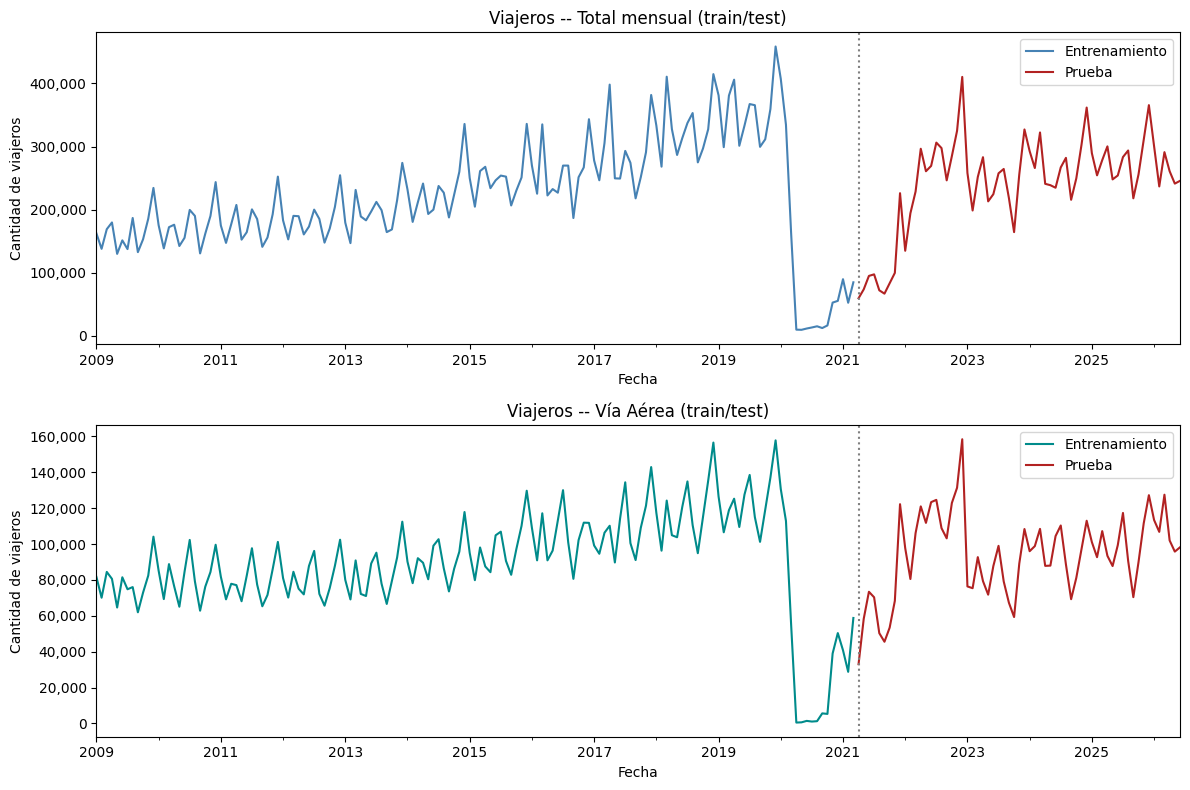

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8))
for ax, slug in zip(axes, train_test):
    d = train_test[slug]
    d["train"].plot(ax=ax, color=d["color"], label="Entrenamiento")
    d["test"].plot(ax=ax, color="firebrick", label="Prueba")
    ax.axvline(SPLIT_DATE, color="gray", linestyle=":")
    ax.set_title(f'Viajeros -- {d["titulo"]} (train/test)')
    ax.set_xlabel("Fecha"); ax.set_ylabel("Cantidad de viajeros")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{x:,.0f}"))
    ax.legend()
plt.tight_layout()
plt.savefig("train_test_split.png", dpi=150, bbox_inches="tight")
plt.show()

## Ejercicio 1.2 — Modelos LSTM: configuraciones y tuneo de hiperparámetros

Para cada una de las dos series (**Total mensual** y **Vía Aérea**) se construyen **dos modelos LSTM con arquitecturas distintas** (una LSTM de una sola capa y una LSTM apilada de dos capas), y para cada arquitectura se realiza un **tuneo de hiperparámetros** (ventana de entrada `look_back`, número de unidades, tasa de aprendizaje, dropout y batch size) mediante una búsqueda en grilla evaluada con un conjunto de validación cronológico (los últimos meses del set de entrenamiento).

**Metodología:**
- Escalado `MinMaxScaler` ajustado únicamente con el set de entrenamiento (evita fuga de información).
- Ventaneo (`sliding window`) para transformar la serie en pares (secuencia de `look_back` meses → siguiente mes).
- Validación cronológica: último 15% del set de entrenamiento, sin mezclar el orden temporal.
- `EarlyStopping` sobre la pérdida de validación para evitar sobreajuste.
- Evaluación final en el set de prueba mediante **pronóstico iterativo (walk-forward)**: cada predicción se reinyecta como parte de la ventana para predecir el siguiente mes, replicando un escenario real de pronóstico a 63 meses.

In [6]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

tf.random.set_seed(42)
np.random.seed(42)

def make_windows(arr, look_back):
    X, y = [], []
    for i in range(len(arr) - look_back):
        X.append(arr[i:i+look_back])
        y.append(arr[i+look_back])
    return np.array(X), np.array(y)

def build_lstm(look_back, units, n_layers, dropout, lr):
    model = keras.Sequential()
    model.add(layers.Input(shape=(look_back, 1)))
    for i in range(n_layers):
        model.add(layers.LSTM(units[i], return_sequences=(i < n_layers - 1)))
        if dropout > 0:
            model.add(layers.Dropout(dropout))
    model.add(layers.Dense(1))
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=lr), loss="mse")
    return model

I0000 00:00:1785538825.229256     604 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1785538825.229870     604 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1785538825.276940     604 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1785538826.623206     604 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1785538826.623681     604 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


### Búsqueda en grilla (tuneo) sobre un conjunto de validación cronológico

In [7]:
def evaluate_config(train_vals, cfg, val_frac=0.15, epochs=60):
    look_back = cfg["look_back"]
    scaler = MinMaxScaler()
    train_scaled = scaler.fit_transform(train_vals.reshape(-1, 1)).flatten()

    n_val = max(look_back + 1, int(len(train_scaled) * val_frac))
    tr, val = train_scaled[:-n_val], train_scaled[-(n_val + look_back):]

    Xtr, ytr = make_windows(tr, look_back)
    Xval, yval = make_windows(val, look_back)
    Xtr, Xval = Xtr.reshape(-1, look_back, 1), Xval.reshape(-1, look_back, 1)

    model = build_lstm(look_back, cfg["units"], cfg["n_layers"], cfg["dropout"], cfg["lr"])
    es = keras.callbacks.EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True)
    hist = model.fit(Xtr, ytr, validation_data=(Xval, yval), epochs=epochs,
                      batch_size=cfg["batch_size"], callbacks=[es], verbose=0)

    pred_val = model.predict(Xval, verbose=0).flatten()
    pred_val_inv = scaler.inverse_transform(pred_val.reshape(-1, 1)).flatten()
    yval_inv = scaler.inverse_transform(yval.reshape(-1, 1)).flatten()
    rmse = np.sqrt(mean_squared_error(yval_inv, pred_val_inv))
    return rmse, len(hist.history["loss"])

# Grilla de hiperparámetros: combina look_back, arquitectura (1 vs 2 capas),
# unidades, dropout, learning rate y batch size
grid = [
    {"look_back": 12, "units": [32],     "n_layers": 1, "dropout": 0.0, "lr": 0.0010, "batch_size": 8},
    {"look_back": 12, "units": [64],     "n_layers": 1, "dropout": 0.2, "lr": 0.0010, "batch_size": 8},
    {"look_back": 24, "units": [64, 32], "n_layers": 2, "dropout": 0.2, "lr": 0.0005, "batch_size": 8},
    {"look_back": 24, "units": [50, 25], "n_layers": 2, "dropout": 0.1, "lr": 0.0010, "batch_size": 16},
    {"look_back": 6,  "units": [128],    "n_layers": 1, "dropout": 0.3, "lr": 0.0001, "batch_size": 4},
    {"look_back": 36, "units": [100, 50, 25], "n_layers": 3, "dropout": 0.2, "lr": 0.0050, "batch_size": 32},
    {"look_back": 12, "units": [32, 16], "n_layers": 2, "dropout": 0.5, "lr": 0.0100, "batch_size": 16},
    {"look_back": 6,  "units": [64, 32, 16], "n_layers": 3, "dropout": 0.1, "lr": 0.0005,  "batch_size": 8},
]

tuning_rows = []
for slug, d in train_test.items():
    train_vals = d["train"].values.astype("float32")
    for i, cfg in enumerate(grid):
        rmse, n_ep = evaluate_config(train_vals, cfg)
        tuning_rows.append({"serie": d["titulo"], "config_id": i, **cfg,
                             "val_rmse": rmse, "epochs_usados": n_ep})

tuning_df = pd.DataFrame(tuning_rows)
tuning_df.sort_values(["serie", "val_rmse"]).reset_index(drop=True)

E0000 00:00:1785538827.721338     604 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


,serie,config_id,look_back,units,n_layers,dropout,lr,batch_size,val_rmse,epochs_usados
0,Total mensual,4,6,[128],1,0.3,0.0001,4,125601.553111,11
1,Total mensual,6,12,"[32, 16]",2,0.5,0.0100,16,129697.188250,24
2,Total mensual,7,6,"[64, 32, 16]",3,0.1,0.0005,8,134247.052020,10
3,Total mensual,5,36,"[100, 50, 25]",3,0.2,0.0050,32,135845.604596,32
4,Total mensual,1,12,[64],1,0.2,0.0010,8,135965.638953,10
5,Total mensual,3,24,"[50, 25]",2,0.1,0.0010,16,149224.485283,11
6,Total mensual,0,12,[32],1,0.0,0.0010,8,156818.539312,10
7,Total mensual,2,24,"[64, 32]",2,0.2,0.0005,8,166940.887071,11
8,Vía Aérea,4,6,[128],1,0.3,0.0001,4,47098.515985,12
9,Vía Aérea,5,36,"[100, 50, 25]",3,0.2,0.0050,32,47595.081427,26


### Modelo adicional: LSTM Bidireccional para Total mensual

Se agrega un modelo **LSTM Bidireccional** con una configuración de arquitectura diferente a las exploradas en la grilla anterior. Se realiza un tuneo de hiperparámetros propio para la serie **Total mensual** usando validación cronológica.

In [8]:
from tensorflow.keras.layers import Bidirectional

def build_bidirectional_lstm(look_back, units, n_layers, dropout, lr):
    model = keras.Sequential()
    model.add(layers.Input(shape=(look_back, 1)))
    for i in range(n_layers):
        return_seq = (i < n_layers - 1)
        model.add(Bidirectional(layers.LSTM(units[i], return_sequences=return_seq)))
        if dropout > 0:
            model.add(layers.Dropout(dropout))
    model.add(layers.Dense(1))
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=lr), loss="mse")
    return model

def evaluate_config_bi(train_vals, cfg, val_frac=0.15, epochs=60):
    look_back = cfg["look_back"]
    scaler = MinMaxScaler()
    train_scaled = scaler.fit_transform(train_vals.reshape(-1, 1)).flatten()
    n_val = max(look_back + 1, int(len(train_scaled) * val_frac))
    tr, val = train_scaled[:-n_val], train_scaled[-(n_val + look_back):]
    Xtr, ytr = make_windows(tr, look_back)
    Xval, yval = make_windows(val, look_back)
    Xtr, Xval = Xtr.reshape(-1, look_back, 1), Xval.reshape(-1, look_back, 1)
    model = build_bidirectional_lstm(look_back, cfg["units"], cfg["n_layers"],
                                      cfg["dropout"], cfg["lr"])
    es = keras.callbacks.EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True)
    hist = model.fit(Xtr, ytr, validation_data=(Xval, yval), epochs=epochs,
                      batch_size=cfg["batch_size"], callbacks=[es], verbose=0)
    pred_val = model.predict(Xval, verbose=0).flatten()
    pred_val_inv = scaler.inverse_transform(pred_val.reshape(-1, 1)).flatten()
    yval_inv = scaler.inverse_transform(yval.reshape(-1, 1)).flatten()
    rmse = np.sqrt(mean_squared_error(yval_inv, pred_val_inv))
    return rmse, len(hist.history["loss"])

# Grilla propia para el modelo Bidireccional con configuraciones diferentes
grid_bi = [
    {"look_back": 6,  "units": [32],       "n_layers": 1, "dropout": 0.0, "lr": 0.0010, "batch_size": 8},
    {"look_back": 12, "units": [64],       "n_layers": 1, "dropout": 0.2, "lr": 0.0005, "batch_size": 16},
    {"look_back": 18, "units": [100, 50],  "n_layers": 2, "dropout": 0.3, "lr": 0.0010, "batch_size": 8},
    {"look_back": 24, "units": [32, 16],   "n_layers": 2, "dropout": 0.1, "lr": 0.0001, "batch_size": 32},
    {"look_back": 12, "units": [128],      "n_layers": 1, "dropout": 0.4, "lr": 0.0050, "batch_size": 4},
    {"look_back": 36, "units": [64, 32, 16], "n_layers": 3, "dropout": 0.25, "lr": 0.0005, "batch_size": 16},
]

tuning_bi_rows = []
slug = "total"
train_vals = train_test[slug]["train"].values.astype("float32")
for i, cfg in enumerate(grid_bi):
    rmse, n_ep = evaluate_config_bi(train_vals, cfg)
    tuning_bi_rows.append({"serie": "Total mensual", "config_id": i, **cfg,
                          "val_rmse": rmse, "epochs_usados": n_ep})

tuning_bi_df = pd.DataFrame(tuning_bi_rows)
tuning_bi_df.sort_values("val_rmse").reset_index(drop=True)

,serie,config_id,look_back,units,n_layers,dropout,lr,batch_size,val_rmse,epochs_usados
0,Total mensual,0,6,[32],1,0.00,0.0010,8,117210.841273,9
1,Total mensual,1,12,[64],1,0.20,0.0005,16,129433.829272,10
2,Total mensual,4,12,[128],1,0.40,0.0050,4,133437.498298,9
3,Total mensual,2,18,"[100, 50]",2,0.30,0.0010,8,144010.068981,9
4,Total mensual,3,24,"[32, 16]",2,0.10,0.0001,32,149125.417927,16
5,Total mensual,5,36,"[64, 32, 16]",3,0.25,0.0005,16,150628.687414,13


### Selección de 2 modelos por serie

De la grilla anterior, para cada serie se seleccionan **dos configuraciones con arquitecturas distintas**: la de menor RMSE de validación entre las LSTM de **una capa** (Modelo A) y la de menor RMSE de validación entre las LSTM **apiladas de dos capas** (Modelo B). Esto garantiza que los dos modelos comparados por serie difieran en profundidad, `look_back`, número de unidades y tasa de aprendizaje, y no solo en una semilla aleatoria.

In [9]:
chosen_cfgs = {}
for slug, d in train_test.items():
    sub = tuning_df[tuning_df["serie"] == d["titulo"]]
    best_1layer = sub[sub["n_layers"] == 1].sort_values("val_rmse").iloc[0]
    best_2layer = sub[sub["n_layers"] == 2].sort_values("val_rmse").iloc[0]
    chosen_cfgs[slug] = {
        "Modelo A (1 capa)": grid[int(best_1layer["config_id"])],
        "Modelo B (2 capas)": grid[int(best_2layer["config_id"])],
    }
    print(f'{d["titulo"]}:')
    for name, cfg in chosen_cfgs[slug].items():
        print(f"  {name}: {cfg}")

Total mensual:
  Modelo A (1 capa): {'look_back': 6, 'units': [128], 'n_layers': 1, 'dropout': 0.3, 'lr': 0.0001, 'batch_size': 4}
  Modelo B (2 capas): {'look_back': 12, 'units': [32, 16], 'n_layers': 2, 'dropout': 0.5, 'lr': 0.01, 'batch_size': 16}
Vía Aérea:
  Modelo A (1 capa): {'look_back': 6, 'units': [128], 'n_layers': 1, 'dropout': 0.3, 'lr': 0.0001, 'batch_size': 4}
  Modelo B (2 capas): {'look_back': 12, 'units': [32, 16], 'n_layers': 2, 'dropout': 0.5, 'lr': 0.01, 'batch_size': 16}


### Entrenamiento final y evaluación en el set de prueba (pronóstico iterativo a 63 meses)

In [10]:
def train_final(train_vals, cfg, epochs=150, val_frac=0.15):
    look_back = cfg["look_back"]
    scaler = MinMaxScaler()
    train_scaled = scaler.fit_transform(train_vals.reshape(-1, 1)).flatten()
    n_val = max(look_back + 1, int(len(train_scaled) * val_frac))
    tr, val = train_scaled[:-n_val], train_scaled[-(n_val + look_back):]
    Xtr, ytr = make_windows(tr, look_back)
    Xval, yval = make_windows(val, look_back)
    Xtr, Xval = Xtr.reshape(-1, look_back, 1), Xval.reshape(-1, look_back, 1)

    model = build_lstm(look_back, cfg["units"], cfg["n_layers"], cfg["dropout"], cfg["lr"])
    es = keras.callbacks.EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)
    hist = model.fit(Xtr, ytr, validation_data=(Xval, yval), epochs=epochs,
                      batch_size=cfg["batch_size"], callbacks=[es], verbose=0)
    return model, scaler, hist

def forecast_test(model, scaler, train_vals, n_steps, look_back):
    history = list(scaler.transform(train_vals.reshape(-1, 1)).flatten()[-look_back:])
    preds = []
    for _ in range(n_steps):
        x = np.array(history[-look_back:]).reshape(1, look_back, 1)
        p = model.predict(x, verbose=0)[0, 0]
        preds.append(p)
        history.append(p)
    return scaler.inverse_transform(np.array(preds).reshape(-1, 1)).flatten()

def calc_metrics(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / np.where(y_true == 0, np.nan, y_true))) * 100
    return rmse, mae, mape

results = {}
summary_rows = []
for slug, d in train_test.items():
    train_vals = d["train"].values.astype("float32")
    test_vals = d["test"].values.astype("float32")
    results[slug] = {}
    for name, cfg in chosen_cfgs[slug].items():
        model, scaler, hist = train_final(train_vals, cfg)
        preds = forecast_test(model, scaler, train_vals, len(test_vals), cfg["look_back"])
        rmse, mae, mape = calc_metrics(test_vals, preds)
        results[slug][name] = {"preds": preds, "rmse": rmse, "mae": mae, "mape": mape, "cfg": cfg}
        summary_rows.append({"serie": d["titulo"], "modelo": name, "look_back": cfg["look_back"],
                              "n_layers": cfg["n_layers"], "units": cfg["units"], "lr": cfg["lr"],
                              "test_RMSE": round(rmse, 1), "test_MAE": round(mae, 1), "test_MAPE_%": round(mape, 2)})

summary_df = pd.DataFrame(summary_rows)
summary_df

,serie,modelo,look_back,n_layers,units,lr,test_RMSE,test_MAE,test_MAPE_%
0,Total mensual,Modelo A (1 capa),6,1,[128],0.0001,157157.7,142716.8,54.369999
1,Total mensual,Modelo B (2 capas),12,2,"[32, 16]",0.0100,153876.7,139583.9,52.779999
2,Vía Aérea,Modelo A (1 capa),6,1,[128],0.0001,59765.9,55202.1,55.540001
3,Vía Aérea,Modelo B (2 capas),12,2,"[32, 16]",0.0100,28857.2,23663.0,23.809999


### Comparación gráfica: real vs. pronóstico de cada modelo LSTM, por serie

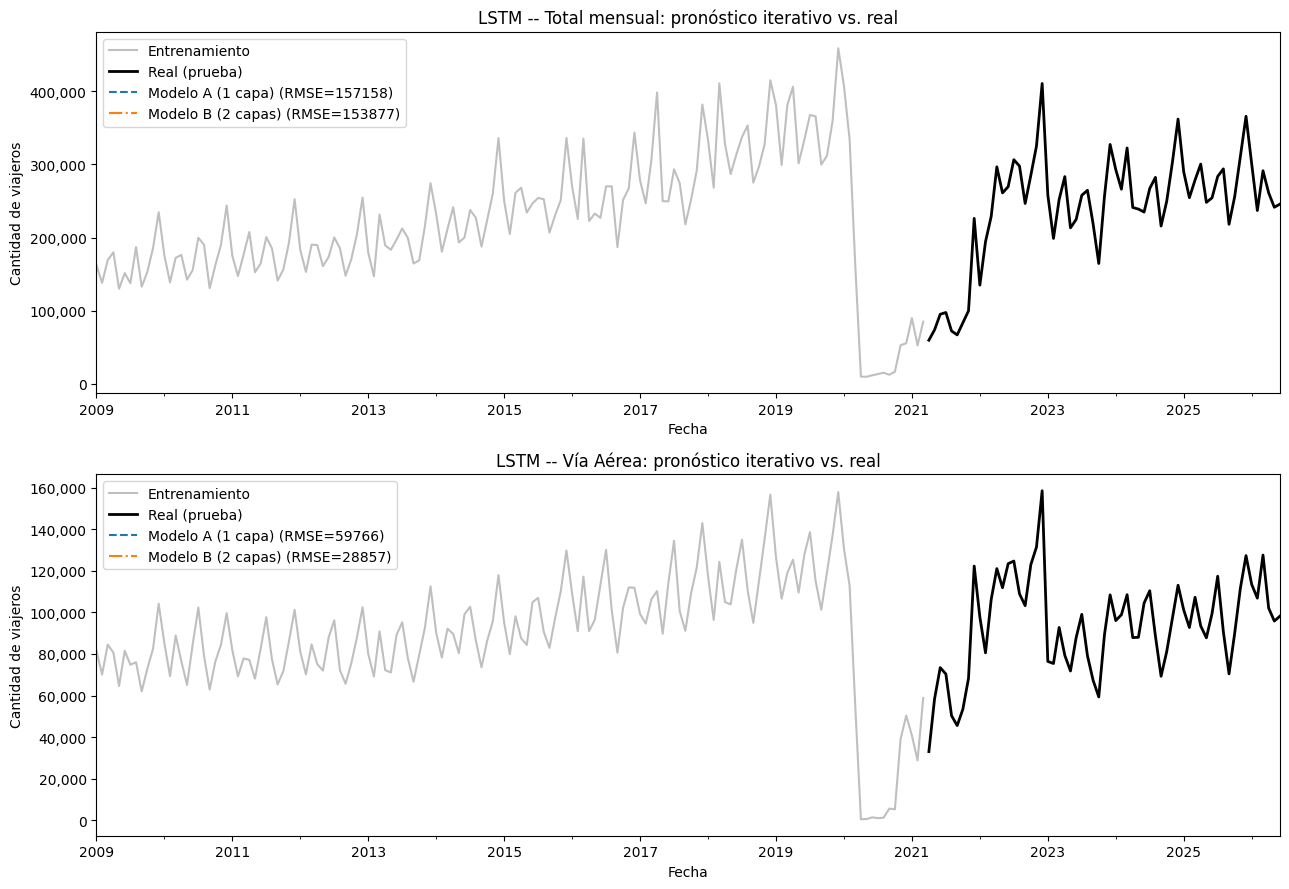

In [11]:
fig, axes = plt.subplots(2, 1, figsize=(13, 9))
for ax, slug in zip(axes, train_test):
    d = train_test[slug]
    d["train"].plot(ax=ax, color="gray", alpha=0.5, label="Entrenamiento")
    d["test"].plot(ax=ax, color="black", linewidth=2, label="Real (prueba)")
    for (name, r), style in zip(results[slug].items(), ["--", "-."]):
        ax.plot(d["test"].index, r["preds"], style, label=f'{name} (RMSE={r["rmse"]:.0f})')
    ax.axvline(SPLIT_DATE, color="gray", linestyle=":")
    ax.set_title(f'LSTM -- {d["titulo"]}: pronóstico iterativo vs. real')
    ax.set_xlabel("Fecha"); ax.set_ylabel("Cantidad de viajeros")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
    ax.legend()
plt.tight_layout()
plt.show()

### Comentario

Con esta ejecución, el **Modelo B (2 capas, look_back=12)** resultó mejor que el Modelo A (1 capa, look_back=6) en el conjunto de prueba para **ambas series**:

- **Total mensual**: Modelo B RMSE≈153,877 (MAPE 52.8%) vs. Modelo A RMSE≈157,158 (MAPE 54.4%). La diferencia es pequeña; ambos modelos tienen un error de prueba muy alto en términos relativos.
- **Vía Aérea**: Modelo B RMSE≈28,857 (MAPE 23.8%) mejora claramente al Modelo A RMSE≈59,766 (MAPE 55.5%), consistente con que capturar dependencias de un año completo (look_back=12) ayuda a modelar mejor la estacionalidad del tráfico aéreo que una ventana de solo 6 meses.

En ambos casos el MAPE de prueba (24%-54%) es notablemente más alto que el de validación, reflejo del quiebre estructural pandemia/pos-pandemia dentro del período de prueba (abril 2021 - junio 2026), el mismo fenómeno que ya afectaba a los modelos ARIMA/Prophet/Holt-Winters del Laboratorio 1. Esto confirma que el mejor RMSE de validación no siempre predice el mejor desempeño fuera de muestra, motivando el uso de dos configuraciones distintas por serie en vez de una sola "ganadora" de la grilla.

### 1.3 Selección del mejor modelo y predicción final

Para cada serie se selecciona, entre el Modelo A (1 capa) y el Modelo B (2 capas), el que obtuvo el **menor RMSE en el conjunto de prueba** (pronóstico iterativo a 63 meses). Ese modelo se usa como la predicción final de cada serie.

In [12]:
best_models = {}
for slug, d in train_test.items():
    modelos = results[slug]
    mejor_nombre = min(modelos, key=lambda n: modelos[n]["rmse"])
    best_models[slug] = mejor_nombre
    print(f'{d["titulo"]}: mejor modelo = {mejor_nombre} '
          f'(RMSE={modelos[mejor_nombre]["rmse"]:.0f}, '
          f'MAE={modelos[mejor_nombre]["mae"]:.0f}, '
          f'MAPE={modelos[mejor_nombre]["mape"]:.1f}%)')

Total mensual: mejor modelo = Modelo B (2 capas) (RMSE=153877, MAE=139584, MAPE=52.8%)
Vía Aérea: mejor modelo = Modelo B (2 capas) (RMSE=28857, MAE=23663, MAPE=23.8%)


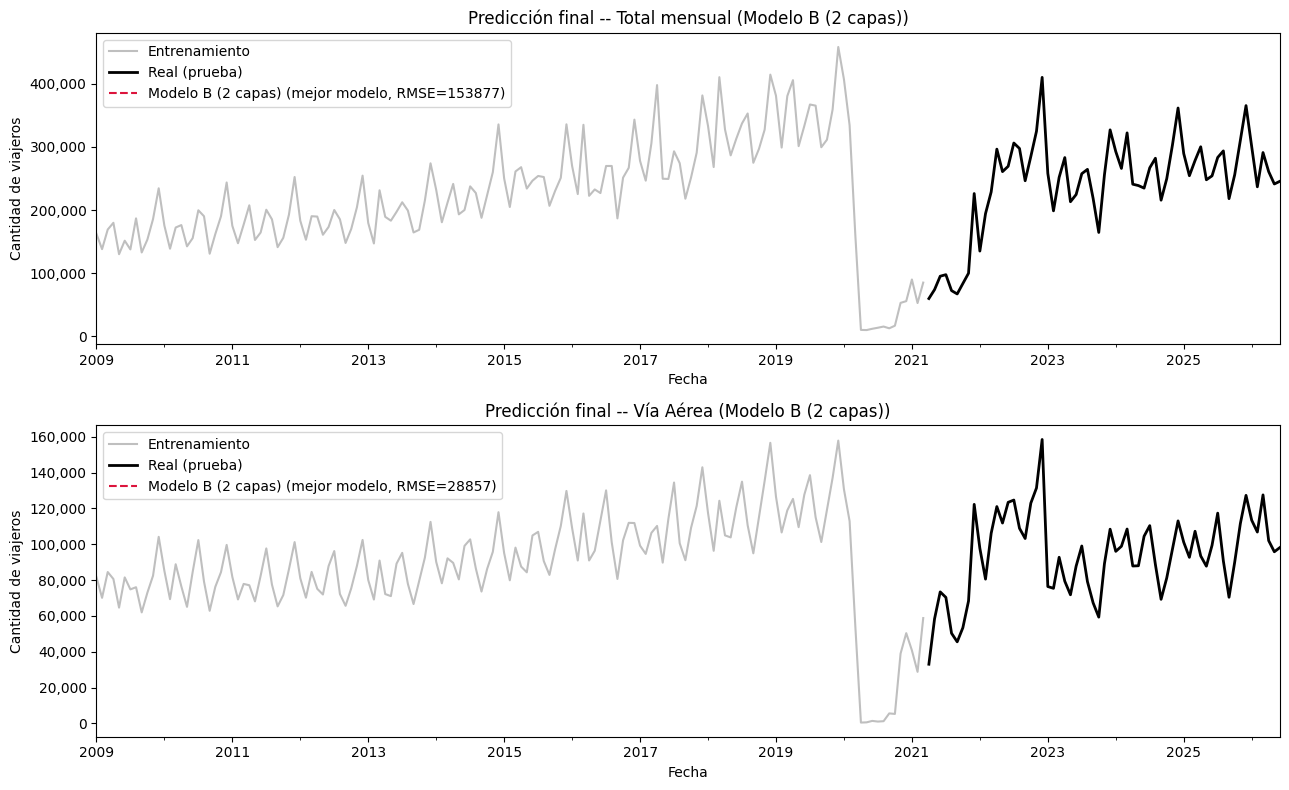

In [13]:
fig, axes = plt.subplots(2, 1, figsize=(13, 8))
for ax, slug in zip(axes, train_test):
    d = train_test[slug]
    nombre = best_models[slug]
    r = results[slug][nombre]
    d["train"].plot(ax=ax, color="gray", alpha=0.5, label="Entrenamiento")
    d["test"].plot(ax=ax, color="black", linewidth=2, label="Real (prueba)")
    ax.plot(d["test"].index, r["preds"], "--", color="crimson",
            label=f'{nombre} (mejor modelo, RMSE={r["rmse"]:.0f})')
    ax.axvline(SPLIT_DATE, color="gray", linestyle=":")
    ax.set_title(f'Predicción final -- {d["titulo"]} ({nombre})')
    ax.set_xlabel("Fecha"); ax.set_ylabel("Cantidad de viajeros")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
    ax.legend()
plt.tight_layout()
plt.savefig("mejor_modelo_prediccion.png", dpi=150, bbox_inches="tight")
plt.show()

In [14]:
pred_tables = {}
for slug, d in train_test.items():
    nombre = best_models[slug]
    r = results[slug][nombre]
    tabla = pd.DataFrame({
        "Real": d["test"].values,
        "Predicción": r["preds"]
    }, index=d["test"].index)
    tabla["Error abs."] = (tabla["Real"] - tabla["Predicción"]).abs()
    pred_tables[slug] = tabla
    print(f'{d["titulo"]} -- {nombre}')
    print(tabla.head(6))
    print("...\n")

Total mensual -- Modelo B (2 capas)
                    Real    Predicción    Error abs.
2021-04-01  59743.190221  57973.343750   1769.846471
2021-05-01  73873.000000  63240.261719  10632.738281
2021-06-01  95146.000000  67364.898438  27781.101562
2021-07-01  97594.664334  70656.156250  26938.508084
2021-08-01  72327.000000  73428.062500   1101.062500
2021-09-01  67023.000000  75893.210938   8870.210938
...

Vía Aérea -- Modelo B (2 capas)
                    Real    Predicción    Error abs.
2021-04-01  33048.102901  57174.796875  24126.693974
2021-05-01  58366.000000  59722.468750   1356.468750
2021-06-01  73416.000000  62124.722656  11291.277344
2021-07-01  70340.000000  64303.179688   6036.820312
2021-08-01  50329.000000  66243.445312  15914.445312
2021-09-01  45551.000000  67943.507812  22392.507813
...



### 1.4 Comparación con el Laboratorio 1

Se compara el RMSE de prueba del mejor modelo LSTM de cada serie contra el RMSE de prueba del mejor modelo del Laboratorio 1 para esa misma serie (ARIMA en ambos casos, según la tabla comparativa de ese laboratorio: ARIMA(1,0,1) con RMSE≈92,266 para Total mensual y RMSE≈30,116 para Vía Aérea).

In [15]:
lab1_rmse = {"total": 92266.0, "aerea": 30116.0}
lab1_modelo = {"total": "ARIMA(1, 0, 1)", "aerea": "ARIMA(1, 0, 1)"}

comparacion_rows = []
for slug, d in train_test.items():
    nombre_lstm = best_models[slug]
    rmse_lstm = results[slug][nombre_lstm]["rmse"]
    rmse_lab1 = lab1_rmse[slug]
    comparacion_rows.append({
        "Serie": d["titulo"],
        "Mejor LSTM": nombre_lstm,
        "RMSE LSTM": round(rmse_lstm, 0),
        "Mejor Lab 1": lab1_modelo[slug],
        "RMSE Lab 1": round(rmse_lab1, 0),
        "Diferencia (LSTM - Lab1)": round(rmse_lstm - rmse_lab1, 0),
        "¿LSTM mejora?": "Sí" if rmse_lstm < rmse_lab1 else "No",
    })
comparacion_df = pd.DataFrame(comparacion_rows)
comparacion_df

,Serie,Mejor LSTM,RMSE LSTM,Mejor Lab 1,RMSE Lab 1,Diferencia (LSTM - Lab1),¿LSTM mejora?
0,Total mensual,Modelo B (2 capas),153877.0,"ARIMA(1, 0, 1)",92266.0,61611.0,No
1,Vía Aérea,Modelo B (2 capas),28857.0,"ARIMA(1, 0, 1)",30116.0,-1259.0,Sí


**¿Cuál predijo mejor, entre los dos modelos LSTM de cada serie?**

El **Modelo B (2 capas, look_back=12)** predijo mejor que el Modelo A en ambas series: RMSE≈153,877 vs. 157,158 en Total mensual, y RMSE≈28,857 vs. 59,766 en Vía Aérea (ver `best_models` y la tabla de la sección 1.2).

**¿Son mejores que los modelos creados en el laboratorio pasado?**

Depende de la serie (ver tabla `comparacion_df`):

- **Total mensual**: el mejor LSTM (RMSE≈153,877) es **peor** que el mejor modelo del Laboratorio 1, ARIMA(1,0,1) (RMSE≈92,266). La diferencia es considerable (≈+61,600 en RMSE, casi 67% peor).
- **Vía Aérea**: el mejor LSTM (RMSE≈28,857) es **ligeramente mejor** que ARIMA(1,0,1) (RMSE≈30,116), una mejora modesta de ≈1,260 en RMSE (≈4%).

En conjunto, la LSTM no superó de forma consistente a los modelos clásicos del Laboratorio 1: para Total mensual el ARIMA simple sigue siendo claramente mejor, mientras que para Vía Aérea la LSTM logra una ventaja pequeña. Esto es consistente con la cantidad relativamente reducida de datos de entrenamiento (147 meses) frente a la complejidad de una red LSTM, que suele necesitar series más largas para explotar plenamente su capacidad de modelar dependencias no lineales.

**¿Cómo lo determinamos?**

En ambos casos (selección entre modelos LSTM y comparación contra el Laboratorio 1) el criterio es el mismo: el **RMSE calculado sobre el conjunto de prueba genuinamente fuera de muestra** (abril 2021 – junio 2026), usando pronóstico iterativo para las LSTM y las predicciones ya generadas en el Laboratorio 1 para ARIMA. Se usa RMSE porque penaliza más los errores grandes y está en las mismas unidades que la variable (cantidad de viajeros), lo que facilita la interpretación frente al MAE o al MAPE.